In [ ]:
import netCDF4
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
print("yey!! all packages imported successfully 😀")

yey!! all packages imported successfully 😀


In [ ]:
ds = xr.open_dataset('data/oco2_LtCO2_231231_B11210Ar_240919184624s.nc4')
print(ds)
print("VARIABLES IN THE DATASET:")
print(list(ds.variables))

<xarray.Dataset> Size: 77MB
Dimensions:                 (sounding_id: 169840, epoch_dimension: 7,
                             vertices: 4, levels: 20, bands: 3,
                             source_files: 16, frames: 120142, footprints: 8)
Coordinates:
  * sounding_id             (sounding_id) float64 1MB 2.023e+15 ... 2.023e+15
  * vertices                (vertices) int16 8B 1 2 3 4
  * levels                  (levels) int16 40B 1 2 3 4 5 6 ... 15 16 17 18 19 20
  * bands                   (bands) int16 6B 1 2 3
  * source_files            (source_files) object 128B 'oco2_L2StdGL_50513a_2...
  * frames                  (frames) int32 481kB 1 2 3 ... 120140 120141 120142
  * footprints              (footprints) int16 16B 1 2 3 4 5 6 7 8
Dimensions without coordinates: epoch_dimension
Data variables: (12/20)
    date                    (sounding_id, epoch_dimension) float32 5MB ...
    latitude                (sounding_id) float32 679kB ...
    longitude               (sounding_id) floa

In [58]:
import os
data_path = 'data'
files = os.listdir(data_path)

In [ ]:
print(f"Number of OCO-2 files found: {len(files)}")
print(files[:2])

Number of OCO-2 files found: 362
['oco2_LtCO2_231231_B11210Ar_240919184624s.nc4', 'oco2_LtCO2_240101_B11210Ar_240919185807s.nc4']


In [ ]:
print("LISTER LES VARIABLES")
print(list(ds.variables))
print("LISTER LES DIMENSIONS")
print(list(ds.dims))
print("LISTER LES COORDONNEES")
print(list(ds.coords))

LISTER LES VARIABLES
['date', 'latitude', 'longitude', 'time', 'solar_zenith_angle', 'sensor_zenith_angle', 'xco2_quality_flag', 'xco2_qf_bitflag', 'xco2_qf_simple_bitflag', 'file_index', 'vertex_latitude', 'vertex_longitude', 'xco2', 'xco2_x2019', 'xco2_uncertainty', 'xco2_apriori', 'pressure_levels', 'co2_profile_apriori', 'xco2_averaging_kernel', 'pressure_weight', 'sounding_id', 'levels', 'bands', 'vertices', 'source_files', 'frames', 'footprints']
LISTER LES DIMENSIONS
['sounding_id', 'epoch_dimension', 'vertices', 'levels', 'bands', 'source_files', 'frames', 'footprints']
LISTER LES COORDONNEES
['sounding_id', 'levels', 'bands', 'vertices', 'source_files', 'frames', 'footprints']


In [ ]:
#xco2 = ds.xco2 ou bien xco2 = ds.variables['xco2'] (mais c'est pas recommandé)
xco2 = ds['xco2']  # retourne un DataArray xarray (Type d’objet : xarray.DataArray)
print(xco2)
print("Shape of xco2:", xco2.shape) # Affiche la taille de matrice ou du vecteur 

<xarray.DataArray 'xco2' (sounding_id: 169840)> Size: 679kB
[169840 values with dtype=float32]
Coordinates:
  * sounding_id  (sounding_id) float64 1MB 2.023e+15 2.023e+15 ... 2.023e+15
Attributes:
    units:        ppm
    long_name:    Bias-corrected XCO2 on X2007 scale
    comment:      Column-averaged dry-air mole fraction of CO2, including bia...
    Coordinates:  time longitude latitude
Shape of xco2: (169840,)


In [ ]:
#créer un dataframe avec les variables d’intérêt : sounding_id, xco2, xco2_uncertainty, xco2_quality_flag, latitude, longitude
df = pd.DataFrame({
    'sounding_id': ds['sounding_id'].values,
    'xco2': ds['xco2'].values,
    'xco2_uncertainty': ds['xco2_uncertainty'].values,
    'xco2_quality_flag': ds['xco2_quality_flag'].values,
    'latitude': ds['latitude'].values,
    'longitude': ds['longitude'].values
})
df_filtered = df[(df['xco2_quality_flag'] == 0) & (df['xco2_uncertainty'] < 2)]
print("Number of valid measurements:", len(df_filtered))
print(df_filtered.head())

Number of valid measurements: 95003
    sounding_id        xco2  xco2_uncertainty  xco2_quality_flag   latitude  \
0  2.023123e+15  421.541870          0.529847                0.0  14.950292   
1  2.023123e+15  421.454926          0.532013                0.0  14.939731   
2  2.023123e+15  421.162079          0.526935                0.0  14.929037   
3  2.023123e+15  421.643280          0.525319                0.0  14.918242   
4  2.023123e+15  420.925415          0.531370                0.0  14.907461   

    longitude  
0 -160.420609  
1 -160.413803  
2 -160.407043  
3 -160.400360  
4 -160.393814  


In [ ]:
print(df_filtered[['latitude','longitude','xco2']].describe())

           latitude     longitude          xco2
count  95003.000000  95003.000000  95003.000000
mean      -4.265988     -8.925823    420.208374
std       25.396587    104.543877      1.476954
min      -77.494560   -179.565811    412.312103
25%      -23.850854   -100.205299    419.263947
50%       -3.427426    -16.831305    420.171478
75%       16.295128     65.668987    421.244141
max       51.421879    179.904831    427.993958


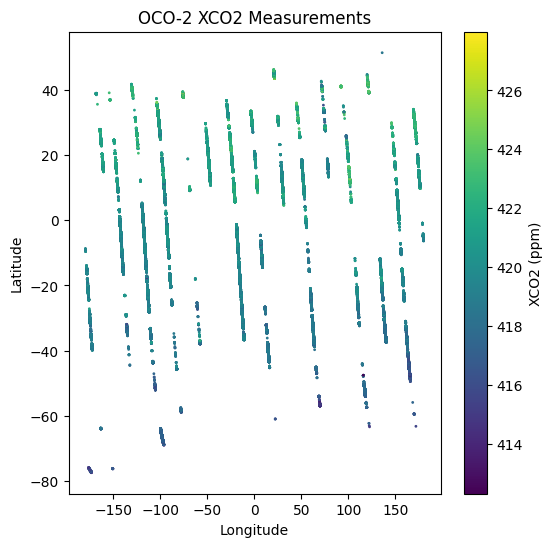

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df_filtered['longitude'], df_filtered['latitude'], c=df_filtered['xco2'], s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('OCO-2 XCO2 Measurements')
plt.colorbar(label='XCO2 (ppm)')
plt.show()

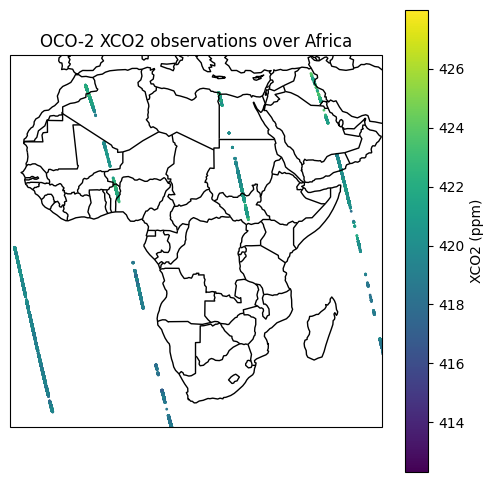

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(6, 6))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

ax.set_extent([-20, 60, -40, 40], crs=ccrs.PlateCarree()) # Pour afficher juste l'Afrique  

sc = ax.scatter(df_filtered['longitude'], df_filtered['latitude'], c=df_filtered['xco2'], s=1, transform=ccrs.PlateCarree())

plt.colorbar(sc, label='XCO2 (ppm)')
plt.title('OCO-2 XCO2 observations over Africa')
plt.show()


In [38]:
input_folder = "data"  # dossier où sont tes nc4
output_folder = "data_csv" # dossier où tu veux stocker les csv
os.makedirs(output_folder, exist_ok=True)

files = [f for f in os.listdir(input_folder) if f.endswith(".nc4")]

for file in files:
    ds = xr.open_dataset(os.path.join(input_folder, file))
    df = pd.DataFrame({
        "sounding_id": ds['sounding_id'].values,
        "xco2": ds['xco2'].values,
        "xco2_uncertainty": ds['xco2_uncertainty'].values,
        "xco2_quality_flag": ds['xco2_quality_flag'].values,
        "latitude": ds['latitude'].values,
        "longitude": ds['longitude'].values
    }) # Convertir les variables d’intérêt en dataframe 
    
    #garder les mesures fiables
    df = df[(df['xco2_quality_flag'] == 0) & (df['xco2_uncertainty'] < 2)]

    df = df.dropna() # Supprimer les lignes avec des valeurs manquantes (NA)
    
    output_file = os.path.join(output_folder,os.path.basename(file) ,file.replace(".nc4",".csv"))

    df.to_csv(os.path.join(output_folder, file.replace(".nc4",".csv")), index=False)
    
    ds.close() # Fermer le dataset après l'avoir utilisé pour libérer la mémoire

In [47]:
import glob #sert à trouver tous les fichiers qui correspondent à un motif (pattern) donné (ici, tous les fichiers .nc4 dans le dossier data)
files = glob.glob(os.path.join(input_folder, "*.nc4")) #on pourra le faire avec os : files = [f for f in os.listdir("data") if f.endswith(".nc4")]
print(f"Number of OCO-2 files found: {len(files)}")
print(files[:5])

Number of OCO-2 files found: 362
['data\\oco2_LtCO2_231231_B11210Ar_240919184624s.nc4', 'data\\oco2_LtCO2_240101_B11210Ar_240919185807s.nc4', 'data\\oco2_LtCO2_240102_B11210Ar_240919185948s.nc4', 'data\\oco2_LtCO2_240103_B11210Ar_240919190052s.nc4', 'data\\oco2_LtCO2_240104_B11210Ar_240919190109s.nc4']


In [39]:
df_all = pd.concat(all_data) #contient toutes les observations OCO-2 de l’année
print(type(all_data)) #liste de dataframes
print(type(df_all)) #pandas dataframe 
print(df_all.shape)
print(df_all.head())
print(df_all.columns)

<class 'list'>
<class 'pandas.DataFrame'>
(29629272, 5)
    sounding_id   latitude   longitude        xco2  xco2_quality_flag
0  2.023123e+15  14.950292 -160.420609  421.541870                0.0
1  2.023123e+15  14.939731 -160.413803  421.454926                0.0
2  2.023123e+15  14.929037 -160.407043  421.162079                0.0
3  2.023123e+15  14.918242 -160.400360  421.643280                0.0
4  2.023123e+15  14.907461 -160.393814  420.925415                0.0
Index(['sounding_id', 'latitude', 'longitude', 'xco2', 'xco2_quality_flag'], dtype='str')


In [40]:
#limiter à l'Afrique : latitude entre -40 et 40, longitude entre -20 et 60
df_africa = df_all[
    (df_all["latitude"] >= -40) &
    (df_all["latitude"] <= 40) &
    (df_all["longitude"] >= -20) &
    (df_all["longitude"] <= 60)
]
print(df_africa.shape)

(5194776, 5)


In [53]:
# Créer une grille 
df_africa['lat_grid'] = df_africa['latitude'].round()
df_africa['lon_grid'] = df_africa['longitude'].round()
print("toutes les observations proches sont regroupées dans la même cellule de la grille")

toutes les observations proches sont regroupées dans la même cellule de la grille


In [54]:
#CO2 moyen par cellule de la grille
grid_co2 = df_africa.groupby(['lat_grid', 'lon_grid'])['xco2'].mean().reset_index()
print(grid_co2.head())
print(grid_co2.shape)

   lat_grid  lon_grid        xco2
0     -40.0     -19.0  418.407745
1     -40.0     -18.0  418.445099
2     -40.0     -17.0  418.396271
3     -40.0     -16.0  418.848541
4     -40.0     -15.0  418.996643
(6270, 3)


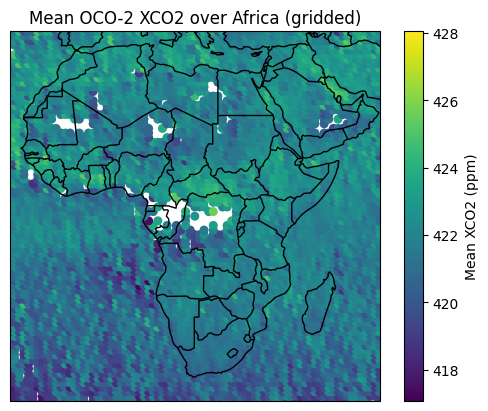

In [55]:
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

ax.set_extent([-20, 60, -40, 40], crs=ccrs.PlateCarree()) # Pour afficher juste l'Afrique

sc = ax.scatter(
    grid_co2["lon_grid"],
    grid_co2["lat_grid"],
    c=grid_co2["xco2"],
    s=30,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, label='Mean XCO2 (ppm)')
plt.title('Mean OCO-2 XCO2 over Africa (gridded)')
plt.show()

In [56]:
grid_co2 = grid_co2.groupby(['lat_grid', 'lon_grid'])['xco2'].mean()

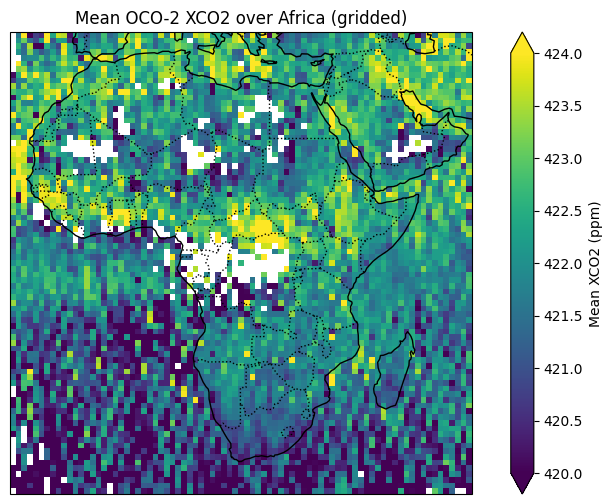

In [57]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

co2_xr = grid_co2.to_xarray()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
co2_xr.plot(ax=ax, transform=ccrs.PlateCarree(), 
            vmin=420, vmax=424, 
            cmap='viridis', cbar_kwargs={'label': 'Mean XCO2 (ppm)'})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Mean OCO-2 XCO2 over Africa (gridded)')
plt.show()